# Lab #02: Exploratory Data Analysis (EDA)

### **Objectives:**
1. **Lab Task #o1:** Find a dataset with outliers, plot graphs, and visually identify & annotate the outliers.
2. **Lab Task #01:** Perform full EDA overview (dimensions, data types), calculate summary statistics (mean, median, std, min, max, IQR), visualize distributions & relationships (histograms, box plots, scatter plots), and discuss observations.
3. **Lab Task #02:** Select a subset of variables, generate advanced visualizations (**Correlation Heatmap**, **Pairwise Scatterplots / Pairplot**, **Time Series Plot**), and interpret patterns & anomalies.

---

## 1. Setup Environment & Load Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

# Load Housing Dataset
csv_path = 'housing_data.csv'
df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset Loaded Successfully! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head()

Dataset Loaded Successfully! Total Rows: 250, Total Columns: 7


,Date,Square_Footage,Bedrooms,Bathrooms,House_Age,Location_Score,Price
0,2023-01-01,2224.0,4,2,35,8.8,509786.0
1,2023-01-02,1938.0,3,2,25,8.6,443705.0
2,2023-01-03,2291.0,5,3,26,3.9,500411.0
3,2023-01-04,2685.0,4,4,11,8.5,637060.0
4,2023-01-05,1895.0,3,1,38,1.3,317786.0


---
## 2. Lab Task #o1: Finding and Identifying Outliers in the Dataset
> **Task:** Find a dataset with outliers. Plot graphs and clearly identify/annotate the outliers.

In [2]:
# Mathematical Outlier Detection using Interquartile Range (IQR)
# Rule: Outliers lie outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

q1_price = df['Price'].quantile(0.25)
q3_price = df['Price'].quantile(0.75)
iqr_price = q3_price - q1_price
lower_price = q1_price - 1.5 * iqr_price
upper_price = q3_price + 1.5 * iqr_price

q1_sqft = df['Square_Footage'].quantile(0.25)
q3_sqft = df['Square_Footage'].quantile(0.75)
iqr_sqft = q3_sqft - q1_sqft
lower_sqft = q1_sqft - 1.5 * iqr_sqft
upper_sqft = q3_sqft + 1.5 * iqr_sqft

price_outliers = df[(df['Price'] < lower_price) | (df['Price'] > upper_price)]
sqft_outliers = df[(df['Square_Footage'] < lower_sqft) | (df['Square_Footage'] > upper_sqft)]
all_outlier_idx = list(set(price_outliers.index).union(set(sqft_outliers.index)))

print(f"[Price IQR Bounds]: Lower = ${lower_price:,.2f} | Upper = ${upper_price:,.2f}")
print(f"Total Price Outliers: {len(price_outliers)}")
print(f"[Square Footage IQR Bounds]: Lower = {lower_sqft:,.2f} sqft | Upper = {upper_sqft:,.2f} sqft")
print(f"Total Square Footage Outliers: {len(sqft_outliers)}")

[Price IQR Bounds]: Lower = $203,644.12 | Upper = $678,771.12
Total Price Outliers: 5
[Square Footage IQR Bounds]: Lower = 795.88 sqft | Upper = 3,170.88 sqft
Total Square Footage Outliers: 4


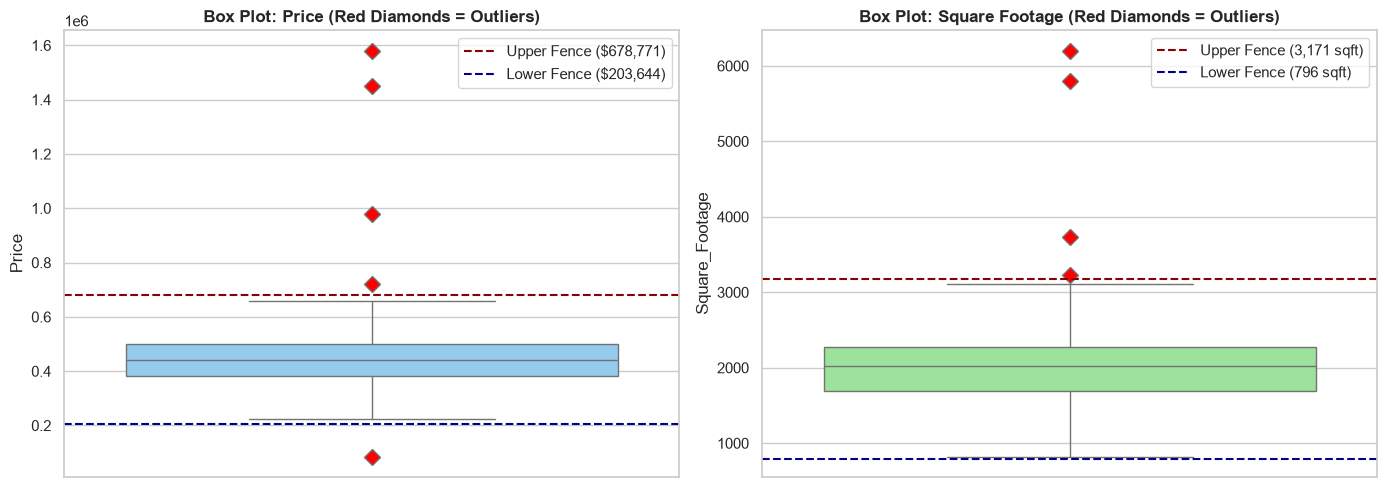

In [3]:
# Box Plots showing Outliers and IQR Fences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price Box Plot
sns.boxplot(y=df['Price'], ax=axes[0], color='lightskyblue', flierprops={'marker':'D', 'markerfacecolor':'red', 'markersize':8})
axes[0].set_title("Box Plot: Price (Red Diamonds = Outliers)", fontweight='bold')
axes[0].axhline(upper_price, color='darkred', linestyle='--', linewidth=1.5, label=f'Upper Fence (${upper_price:,.0f})')
axes[0].axhline(lower_price, color='darkblue', linestyle='--', linewidth=1.5, label=f'Lower Fence (${lower_price:,.0f})')
axes[0].legend(loc='upper right')

# Square Footage Box Plot
sns.boxplot(y=df['Square_Footage'], ax=axes[1], color='lightgreen', flierprops={'marker':'D', 'markerfacecolor':'red', 'markersize':8})
axes[1].set_title("Box Plot: Square Footage (Red Diamonds = Outliers)", fontweight='bold')
axes[1].axhline(upper_sqft, color='darkred', linestyle='--', linewidth=1.5, label=f'Upper Fence ({upper_sqft:,.0f} sqft)')
axes[1].axhline(lower_sqft, color='darkblue', linestyle='--', linewidth=1.5, label=f'Lower Fence ({lower_sqft:,.0f} sqft)')
axes[1].legend(loc='upper right')

plt.show()

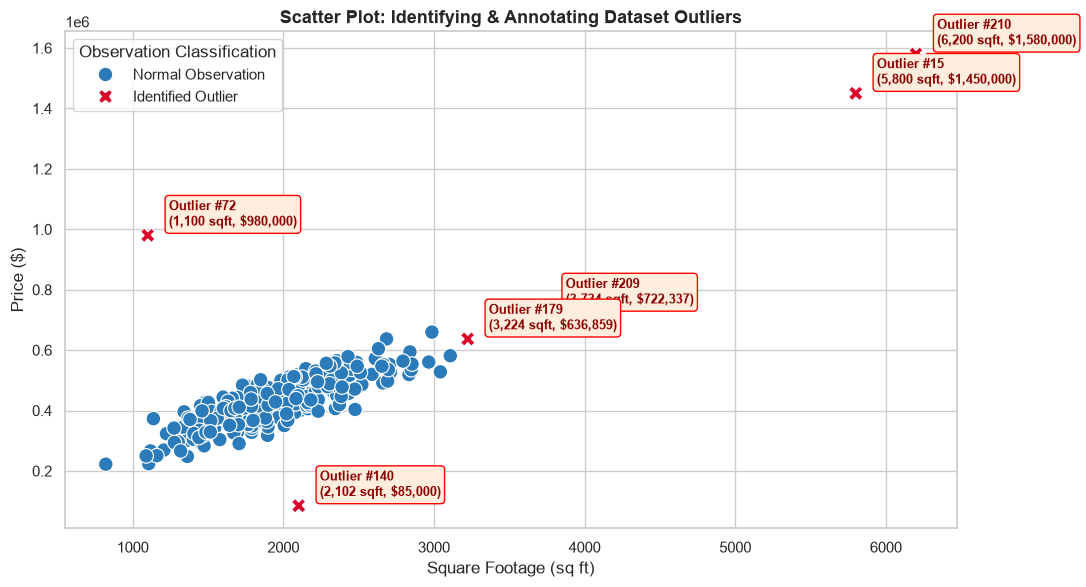

In [4]:
# Scatter Plot with Annotated Outlier Callouts
df['Data_Type'] = 'Normal Observation'
df.loc[all_outlier_idx, 'Data_Type'] = 'Identified Outlier'

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x='Square_Footage',
    y='Price',
    hue='Data_Type',
    style='Data_Type',
    palette={'Normal Observation': '#2b7bba', 'Identified Outlier': '#d90429'},
    markers={'Normal Observation': 'o', 'Identified Outlier': 'X'},
    s=110
)

# Annotate every detected outlier
for idx in all_outlier_idx:
    sq = df.loc[idx, 'Square_Footage']
    pr = df.loc[idx, 'Price']
    plt.annotate(
        f"Outlier #{idx}\n({sq:,.0f} sqft, ${pr:,.0f})",
        xy=(sq, pr),
        xytext=(sq + 140, pr + 32000),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
        fontsize=9,
        fontweight='bold',
        color='darkred',
        bbox=dict(boxstyle="round,pad=0.3", fc="#ffeedd", ec="red")
    )

plt.title("Scatter Plot: Identifying & Annotating Dataset Outliers", fontsize=13, fontweight='bold')
plt.xlabel("Square Footage (sq ft)")
plt.ylabel("Price ($)")
plt.legend(title="Observation Classification")
plt.show()

---
## 3. Lab Task #01: Full EDA Overview, Summary Statistics & Distributions
> **Task:** Provide dataset overview, calculate summary statistics (mean, median, std, min, max), create distribution & relationship plots, and discuss observations.

In [5]:
# Dataset Overview: Shape, Data Types & Info
print("=== DATASET INFORMATION ===")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

=== DATASET INFORMATION ===
Shape: 250 rows, 8 columns

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            250 non-null    datetime64[us]
 1   Square_Footage  250 non-null    float64       
 2   Bedrooms        250 non-null    int64         
 3   Bathrooms       250 non-null    int64         
 4   House_Age       250 non-null    int64         
 5   Location_Score  250 non-null    float64       
 6   Price           250 non-null    float64       
 7   Data_Type       250 non-null    str           
dtypes: datetime64[us](1), float64(3), int64(3), str(1)
memory usage: 15.8 KB


In [6]:
# Summary Statistics for Key Variables
summary = df.describe().T
summary['median'] = df.median(numeric_only=True)
summary['variance'] = df.var(numeric_only=True)
summary['IQR'] = summary['75%'] - summary['25%']

# Display Key Metrics
summary[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'IQR']].round(2)

,count,mean,median,std,min,25%,75%,max,IQR
Date,250,2023-05-05 12:00:00,NaN,NaN,2023-01-01 00:00:00,2023-03-04 06:00:00,2023-07-06 18:00:00,2023-09-07 00:00:00,124 days 12:00:00
Square_Footage,250.0,2027.352,2028.0,565.516173,821.0,1686.5,2280.25,6200.0,593.75
Bedrooms,250.0,3.364,3.0,0.969155,2.0,3.0,4.0,5.0,1.0
Bathrooms,250.0,2.236,2.0,0.814221,1.0,2.0,3.0,4.0,1.0
House_Age,250.0,20.62,21.0,10.908326,1.0,11.0,29.75,39.0,18.75
Location_Score,250.0,5.6644,5.9,2.691436,1.1,3.15,8.0,10.0,4.85
Price,250.0,448549.192,442190.5,133660.929455,85000.0,381816.75,500598.5,1580000.0,118781.75


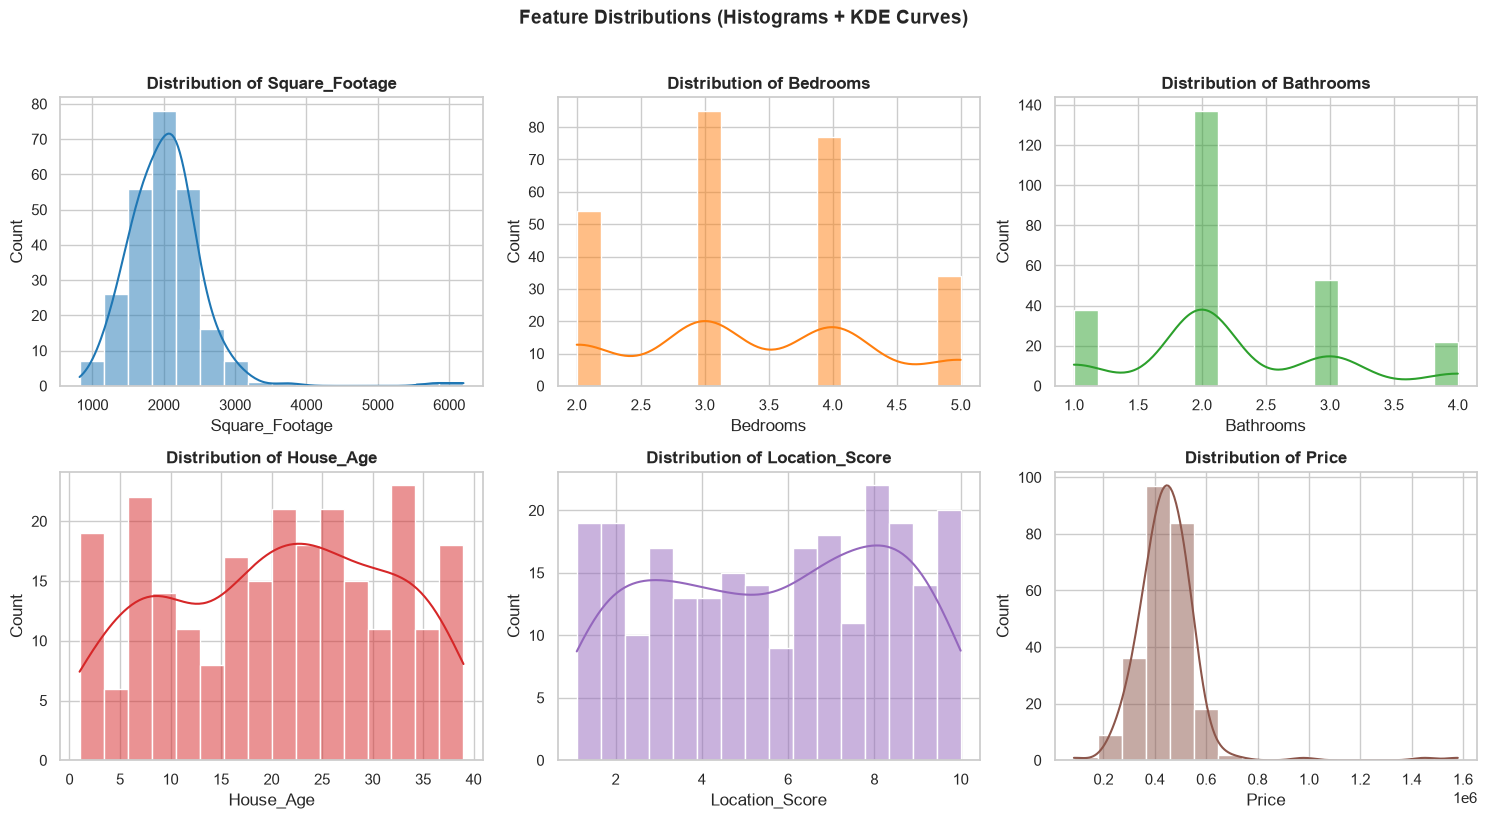

In [7]:
# Histograms with Kernel Density Estimation (KDE)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Square_Footage', 'Bedrooms', 'Bathrooms', 'House_Age', 'Location_Score', 'Price']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[i], bins=16)
    ax.set_title(f'Distribution of {col}', fontweight='bold')

plt.suptitle("Feature Distributions (Histograms + KDE Curves)", y=1.02, fontsize=14, fontweight='bold')
plt.show()

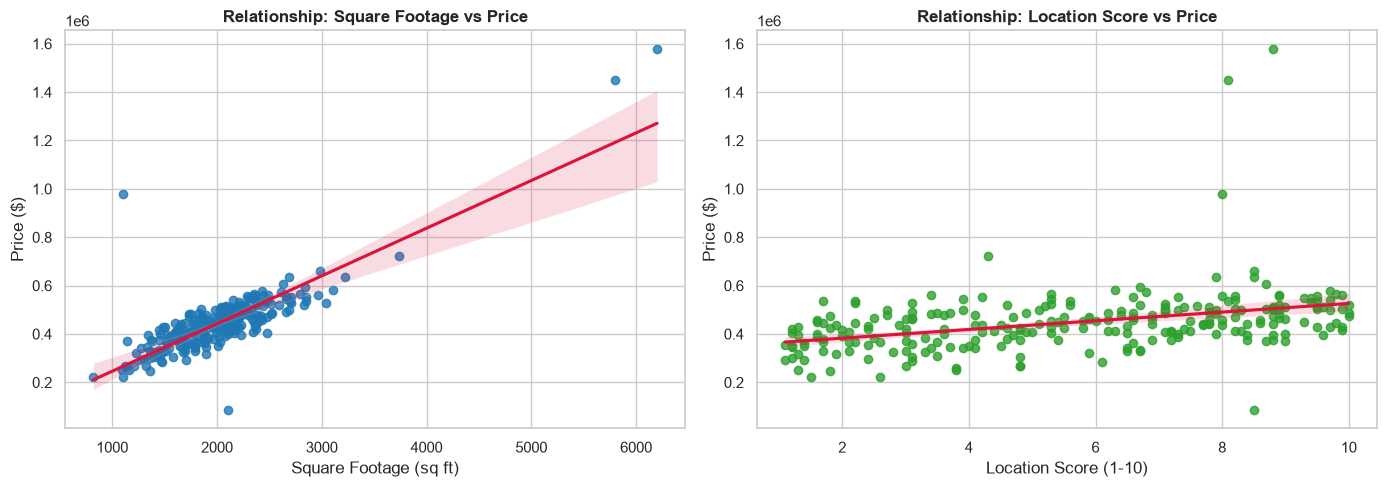

In [8]:
# Bivariate Scatter Relationships with Linear Fit Lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Square Footage vs Price
sns.regplot(data=df, x='Square_Footage', y='Price', ax=axes[0], color='#1f77b4', line_kws={'color':'crimson'})
axes[0].set_title('Relationship: Square Footage vs Price', fontweight='bold')
axes[0].set_xlabel('Square Footage (sq ft)')
axes[0].set_ylabel('Price ($)')

# Location Score vs Price
sns.regplot(data=df, x='Location_Score', y='Price', ax=axes[1], color='#2ca02c', line_kws={'color':'crimson'})
axes[1].set_title('Relationship: Location Score vs Price', fontweight='bold')
axes[1].set_xlabel('Location Score (1-10)')
axes[1].set_ylabel('Price ($)')

plt.show()

### **Task 01 Observations & Insights:**
1. **Distributions:** `Square_Footage` follows an approximate normal distribution (mean $\approx 2,027\text{ sq ft}$, median $\approx 2,028\text{ sq ft}$). `Price` has a right-skewed tail due to luxury estates over \$1,000,000.
2. **Relationships:** `Square_Footage` demonstrates the strongest linear correlation with `Price`. `Location_Score` also adds a positive valuation premium.
3. **Outliers:** Distinct points (e.g. \$1.45M and \$1.58M) represent luxury mansions (>5,500 sq ft), while \$85k represents a distressed property.

---
## 4. Lab Task #02: Subset Selection, Advanced Visualizations & Interpretation
> **Task:** Choose a subset of variables, generate advanced visualizations (Heatmap, Pairwise scatterplots, Time Series), and interpret relationships and patterns.

In [9]:
# Select Subset of Variables
subset_cols = ['Square_Footage', 'Bedrooms', 'Bathrooms', 'House_Age', 'Location_Score', 'Price']
subset_df = df[subset_cols]
subset_df.head()

,Square_Footage,Bedrooms,Bathrooms,House_Age,Location_Score,Price
0,2224.0,4,2,35,8.8,509786.0
1,1938.0,3,2,25,8.6,443705.0
2,2291.0,5,3,26,3.9,500411.0
3,2685.0,4,4,11,8.5,637060.0
4,1895.0,3,1,38,1.3,317786.0


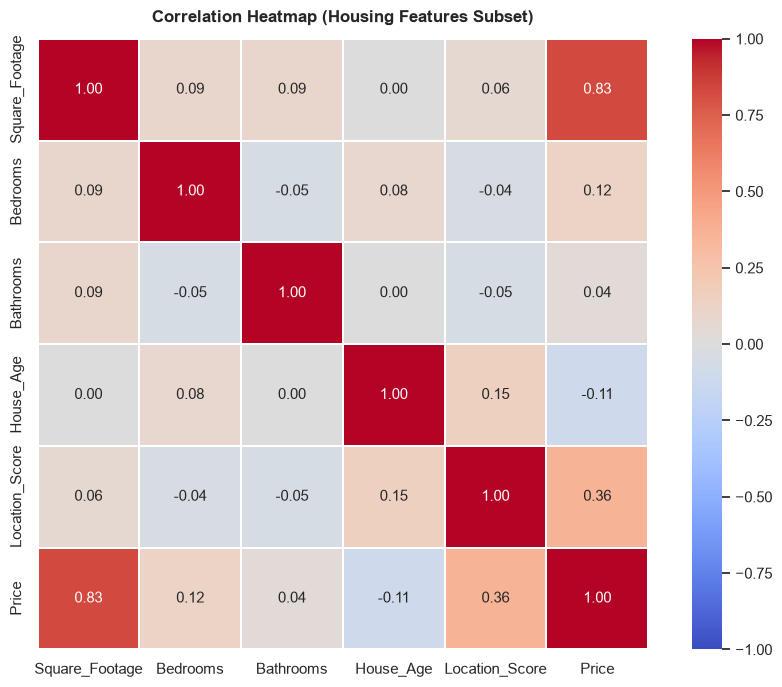

In [10]:
# Advanced Visualization 1: Correlation Heatmap
plt.figure(figsize=(9, 7))
corr = subset_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=1.2)
plt.title("Correlation Heatmap (Housing Features Subset)", fontweight='bold', pad=12)
plt.show()

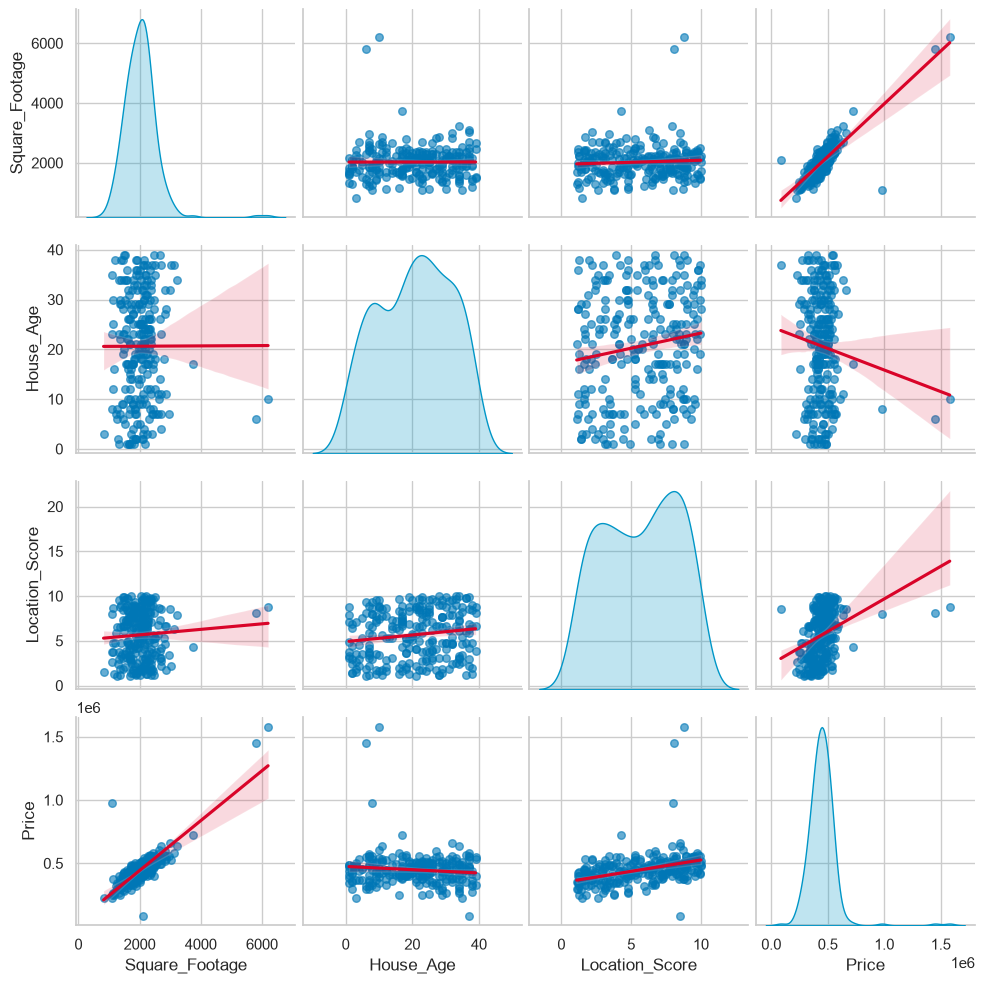

In [ ]:
# Advanced Visualization 2: Pairwise Scatterplots (Pairplot)
sns.pairplot(
    df[['Square_Footage', 'House_Age', 'Location_Score', 'Price']],
    diag_kind='kde',
    kind='reg',
    plot_kws={'scatter_kws': {'alpha': 0.6, 'color': '#0077b6', 's': 30}, 'line_kws': {'color': '#d90429'}},
    diag_kws={'color': '#0096c7', 'fill': True}
)
plt.show()

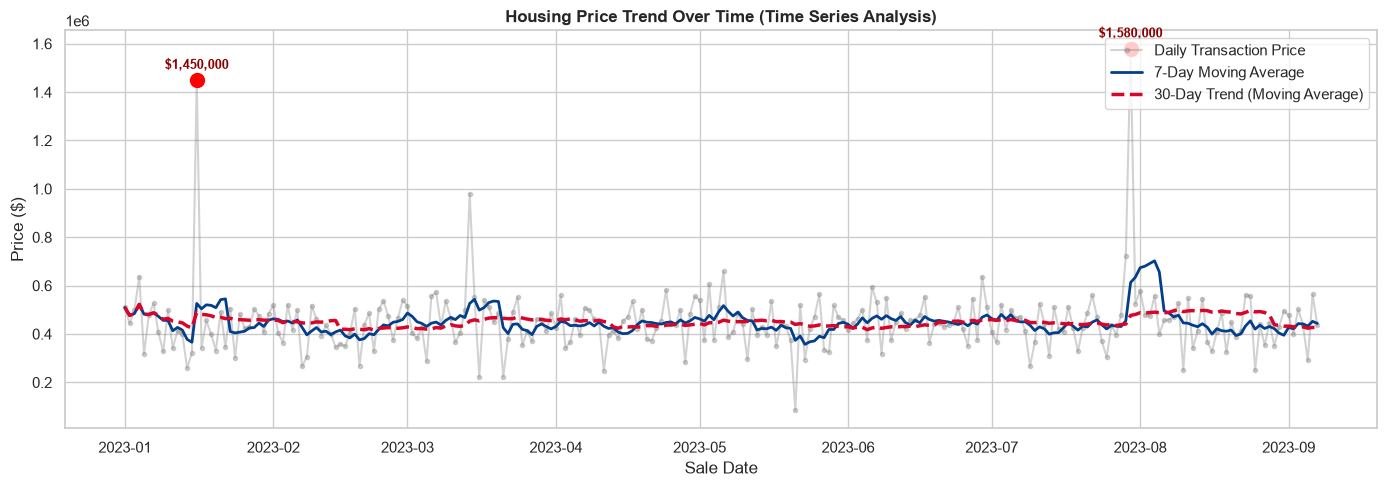

In [ ]:
# Advanced Visualization 3: Time Series Plot with Moving Averages
df_sorted = df.sort_values('Date').copy()
df_sorted['Price_7D_MA'] = df_sorted['Price'].rolling(window=7, min_periods=1).mean()
df_sorted['Price_30D_MA'] = df_sorted['Price'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_sorted['Date'], df_sorted['Price'], marker='o', markersize=3, alpha=0.35, color='gray', label='Daily Transaction Price')
plt.plot(df_sorted['Date'], df_sorted['Price_7D_MA'], color='#023e8a', linewidth=2, label='7-Day Moving Average')
plt.plot(df_sorted['Date'], df_sorted['Price_30D_MA'], color='#d90429', linewidth=2.5, linestyle='--', label='30-Day Trend (Moving Average)')

# Highlight outlier transactions
outliers = df_sorted[df_sorted['Price'] > 1200000]
for _, row in outliers.iterrows():
    plt.scatter(row['Date'], row['Price'], color='red', s=100, zorder=5)
    plt.annotate(f"${row['Price']:,.0f}", (row['Date'], row['Price']), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9, fontweight='bold', color='darkred')

plt.title("Housing Price Trend Over Time (Time Series Analysis)", fontweight='bold')
plt.xlabel("Sale Date")
plt.ylabel("Price ($)")
plt.legend(loc='upper right')
plt.show()

### **Task 02 Advanced Interpretations:**
1. **Correlation Matrix:**
   - `Square_Footage` vs `Price` ($r = +0.83$): Strongest positive predictor.
   - `Location_Score` vs `Price` ($r = +0.36$): Higher neighborhood rating adds substantial property value.
   - `House_Age` vs `Price` ($r = -0.11$): Negative correlation reflecting age depreciation.
2. **Multivariate Pairwise Scatterplots:**
   - Size vs Price shows tight upward linear alignment. Age vs Price shows wide dispersion across ages.
3. **Time Series:**
   - The 7-day and 30-day moving average baselines remain steady around \$420k - \$460k. Isolated peaks represent luxury transactions.